<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">
<h1 style="font-family:verdana; color:#5A4636; text-align:center;">
GARUDA (Gated Adaptive Retrieval-augmented Unsupervised Distillation Architecture)<br><span style="font-size:22px;">Klasifikasi Sentimen Teks Ekonomi Indonesia</span></h1>
<p style="text-align:center; color:#6F5C4F;">Notebook Final | SPSS 2026 | Ensemble Lima Anggota</p>



# Daftar Isi
1. [Pendahuluan](#1)
2. [Problem Statement dan Ketentuan](#2)
3. [Dataset Overview](#3)
4. [Initialization dan Config](#4)
5. [Exploratory Data Analysis](#5)
6. [Preprocessing dan Validasi](#6)
7. [Modelling](#7)
8. [Training, Retraining, dan Submission](#8)
9. [Reproducibility dan Pemeriksaan Akhir](#9)
10. [Interpretasi dan Referensi](#10)
11. [Post-Mortem Analysis](#11)

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# 1. Pendahuluan <a id="1"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

Sentimen berita ekonomi bergantung pada konteks. Kenaikan suku bunga, misalnya,
dapat berdampak berbeda bagi pelaku usaha dan pemberi pinjaman. Kalimat juga dapat
menggabungkan informasi positif dan negatif dalam satu judul.

Garuda menggabungkan representasi bahasa Indonesia, representasi multibahasa,
model sentimen Twitter, dan fitur kata serta karakter. Lima prediksi akhir dirata-ratakan
dengan bobot tetap 0,2. Tidak ada pencarian bobot atau koreksi label manual.

Versi ini membangun ulang lima anggota Garuda setelah audit asal pretrained.
Teacher pseudo-label diganti dengan anggota yang sumbernya tercatat di notebook.
Hasilnya merupakan versi baru, bukan klaim pengulangan identik dari hasil eksperimen lama.

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# 2. Problem Statement dan Ketentuan <a id="2"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

Setiap `kalimat` dipetakan ke `NEGATIF`, `NETRAL`, atau `POSITIF`.
Metrik validasi adalah macro F1, yaitu rata-rata F1 ketiga kelas:

$$\mathrm{Macro\ F1}=\frac{1}{3}\sum_{c=1}^{3}\frac{2TP_c}{2TP_c+FP_c+FN_c}.$$

| Ketentuan | Penerapan |
|---|---|
| Dataset resmi saja | Membaca `Dataset/train.csv` dan `Dataset/test.csv` |
| Label training | Hanya kolom `sentiment` pada train resmi |
| Fitur klasifikasi | Hanya teks `kalimat`; `id` dipakai untuk urutan submission |
| Encoder pretrained | Empat sumber publik dengan revision dan checksum tetap |
| Pseudo-label | Prediksi encoder yang dilatih dalam run ini, dengan filter kesepakatan lexical |
| Batas ensemble | Lima anggota, termasuk classifier lexical |
| Validasi | Teacher dan student memakai split yang sama; label validasi tidak dipakai melatih teacher |

Tidak ada layanan generatif, pengambilan dataset tambahan, pembacaan submission lama,
atau pemuatan checkpoint hasil eksperimen. Bobot pretrained asli merupakan satu-satunya
bobot yang dibaca dari disk. Semua bobot hasil fine-tuning dibuat ulang dalam memori.

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# 3. Dataset Overview <a id="3"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

Struktur input yang diperlukan:

```text
Dataset/
  train.csv   # id, kalimat, sentiment
  test.csv    # id, kalimat
```

Jumlah baris, distribusi kelas, duplikasi, serta panjang teks dihitung dari file yang
dibaca saat eksekusi. Setiap file input dicatat SHA-256-nya agar perubahan data dapat
dibedakan dari perubahan kode atau lingkungan.

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# 4. Initialization dan Config <a id="4"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

## 4.1 Lingkungan eksekusi

Gunakan kernel Python dari `E:/datsci/conda_envs/kaggle-py311-d/python.exe` untuk
mereplikasi pengujian lokal. Paket dan versinya diperiksa di bawah. Pada komputer baru,
pasang versi yang tercantum sebelum menjalankan notebook. GPU CUDA dengan dukungan
BF16 diperlukan; model dilatih satu per satu agar penggunaan memori tetap terkendali.

Variabel cuBLAS ditetapkan sebelum impor PyTorch. `PYTHONHASHSEED=42` harus ditetapkan
saat meluncurkan kernel untuk menyamakan hash Python lintas proses. Algoritma training
di sini tidak mengandalkan urutan iterasi set atau nilai hash Python.

In [1]:
import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["HF_HUB_DISABLE_XET"] = "1"
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

import gc
import hashlib
import html
import importlib.metadata
import json
import math
import platform
import random
import re
import sys
import time
import unicodedata
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from IPython.display import display
from huggingface_hub import snapshot_download
from huggingface_hub.errors import LocalEntryNotFoundError
from scipy.special import softmax
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import FeatureUnion
from sklearn.svm import SVC
from transformers import (
    AutoConfig, AutoModelForSequenceClassification, AutoTokenizer,
    get_cosine_schedule_with_warmup,
)
from transformers.utils import logging as transformer_logging
transformer_logging.set_verbosity_error()

## 4.2 Config

`SMOKE_TEST=True` menjalankan satu epoch pada **setiap** model neural untuk validasi
dan training penuh, dengan seluruh baris data. SVC tidak memiliki parameter epoch.
Smoke test menggunakan direktori berbeda dan nama CSV yang tidak menyerupai submission final.
Setelah smoke test lolos, ubah ke `False`, restart kernel, dan jalankan semua cell.

Epoch training dipisahkan dari horizon scheduler. IndoBERT dan Twitter student
berhenti setelah epoch 6 pada kurva scheduler 8 epoch, sesuai resep Garuda.
Twitter sentiment full juga mempertahankan horizon 8. XLM-R memakai 6/6.

In [2]:
class Config:
    ROOT = next((p for p in (Path.cwd(), Path.cwd().parent)
                 if (p / "Dataset/train.csv").is_file()), Path.cwd())
    SMOKE_TEST = False
    RUN_TAG = 'final'
    CACHE_DIR = Path(r"D:\cache_moved\huggingface\hub")
    SEED = 42
    N_SPLITS = 5
    VALIDATION_FOLD = 0
    BATCH_SIZE = 16
    NUM_THREADS = 6
    PSEUDO_THRESHOLD = 0.95
    WEIGHT_DECAY = 0.01
    WARMUP_RATIO = 0.1
    LABELS = ("NEGATIF", "NETRAL", "POSITIF")
    RECIPES = {
        "indobert": dict(source="indobert", epochs=6, schedule=8, lr=2e-5,
                         head_lr=5e-5, maxlen=96, clean=True, llrd=0.9,
                         rdrop=0.5, mask=0.0, legacy=False),
        "twitter_sentiment": dict(source="twitter_sentiment", epochs=6, schedule=8,
                         lr=2e-5, head_lr=2e-5, maxlen=96, clean=False, llrd=1.0,
                         rdrop=0.0, mask=0.0, legacy=False),
        "xlmr": dict(source="xlmr", epochs=6, schedule=6, lr=1e-5,
                         head_lr=5e-5, maxlen=64, clean=False, llrd=1.0,
                         rdrop=0.0, mask=0.0, legacy=True),
        "twitter_student": dict(source="twitter_large", epochs=6, schedule=8,
                         lr=1e-5, head_lr=5e-5, maxlen=96, clean=True, llrd=1.0,
                         rdrop=0.5, mask=0.1, legacy=False),
    }
    ENSEMBLE_MEMBERS = ("indobert", "lexical", "twitter_student", "twitter_sentiment", "xlmr")
    TEACHER_MEMBERS = ("indobert", "twitter_sentiment", "xlmr")

cfg = Config()
output_dir = cfg.ROOT / "outputs" / ("garuda_smoke_" if cfg.SMOKE_TEST else "garuda_")
output_dir = output_dir.with_name(output_dir.name + cfg.RUN_TAG)
output_dir.mkdir(parents=True, exist_ok=True)
assert len(cfg.ENSEMBLE_MEMBERS) == 5
display(pd.DataFrame(cfg.RECIPES).T)
print("Mode:", "SMOKE" if cfg.SMOKE_TEST else "FULL", "| Output:", output_dir)

,source,epochs,schedule,lr,head_lr,maxlen,clean,llrd,rdrop,mask,legacy
indobert,indobert,6,8,0.00002,0.00005,96,True,0.9,0.5,0.0,False
twitter_sentiment,twitter_sentiment,6,8,0.00002,0.00002,96,False,1.0,0.0,0.0,False
xlmr,xlmr,6,6,0.00001,0.00005,64,False,1.0,0.0,0.0,True
twitter_student,twitter_large,6,8,0.00001,0.00005,96,True,1.0,0.5,0.1,False


Mode: FULL | Output: E:\datsci\spss-2026\outputs\garuda_final


## 4.3 Seed dan algoritma deterministik

Seed diulang sebelum inisialisasi setiap model. Dropout, masking, urutan minibatch,
dan inisialisasi head menggunakan seed ini. Attention memakai implementasi eager;
TF32 dan kernel attention yang tidak deterministik dimatikan. Operasi yang tidak
mendukung determinisme akan menimbulkan error, bukan hanya peringatan.

Kesamaan bit ditargetkan pada perangkat dan versi pustaka yang sama. Perubahan GPU,
driver, PyTorch, tokenizer, atau algoritma attention dapat mengubah hasil numerik.

In [3]:
EXPECTED_VERSIONS = {
    "torch": "2.9.1+cu128", "transformers": "5.15.1", "huggingface-hub": "1.28.0",
    "tokenizers": "0.22.2", "numpy": "2.4.6", "pandas": "3.0.3",
    "scikit-learn": "1.7.2", "scipy": "1.17.1", "matplotlib": "3.10.8",
    "sentencepiece": "0.2.2", "safetensors": "0.8.0", "protobuf": "7.35.1",
}
versions = {name: importlib.metadata.version(name) for name in EXPECTED_VERSIONS}
assert versions == EXPECTED_VERSIONS, ("Samakan versi paket sebelum mereplikasi.", versions)
assert torch.cuda.is_available() and torch.cuda.is_bf16_supported()
torch.set_num_threads(cfg.NUM_THREADS)
torch.cuda.set_per_process_memory_fraction(0.84)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False
torch.backends.cuda.enable_flash_sdp(False)
torch.backends.cuda.enable_mem_efficient_sdp(False)
torch.backends.cuda.enable_math_sdp(True)
torch.use_deterministic_algorithms(True, warn_only=False)

def seed_everything():
    random.seed(cfg.SEED)
    np.random.seed(cfg.SEED)
    torch.manual_seed(cfg.SEED)
    torch.cuda.manual_seed_all(cfg.SEED)

def file_hash(path):
    with Path(path).open("rb") as handle:
        return hashlib.file_digest(handle, "sha256").hexdigest()

seed_everything()
environment = dict(versions=versions, python=sys.version, platform=platform.platform(),
                   gpu=torch.cuda.get_device_name(), cuda=torch.version.cuda,
                   attention="eager", deterministic=True, hash_seed=os.getenv("PYTHONHASHSEED"))
display(pd.Series(environment))

versions         {'torch': '2.9.1+cu128', 'transformers': '5.15...
python           3.11.15 | packaged by Anaconda, Inc. | (main, ...
platform                                 Windows-10-10.0.26200-SP0
gpu                                     NVIDIA GeForce RTX 5060 Ti
cuda                                                          12.8
attention                                                    eager
deterministic                                                 True
hash_seed                                                       42
dtype: object

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# 5. Exploratory Data Analysis <a id="5"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

## 5.1 Membaca data dan memeriksa schema

Pemeriksaan ini menolak ID duplikat, teks kosong, dan label di luar tiga kelas.
Kolom tambahan pada test tidak dibaca. Urutan test asli dipertahankan sampai ekspor.

In [4]:
train_path, test_path = cfg.ROOT / "Dataset/train.csv", cfg.ROOT / "Dataset/test.csv"
train = pd.read_csv(train_path, usecols=["id", "kalimat", "sentiment"])
test = pd.read_csv(test_path, usecols=["id", "kalimat"])
for frame in (train, test):
    assert frame.id.is_unique and frame.notna().all().all()
    assert frame.kalimat.map(lambda x: isinstance(x, str) and bool(x.strip())).all()
assert set(train.sentiment) == set(cfg.LABELS)
y = train.sentiment.map(dict(zip(cfg.LABELS, range(3)))).to_numpy(dtype=np.int64)
input_hashes = {"train": file_hash(train_path), "test": file_hash(test_path)}
display(pd.DataFrame({"split": ["train", "test"], "baris": [len(train), len(test)]}))
display(train.head())

,split,baris
0,train,1526
1,test,654


,id,kalimat,sentiment
0,1,Breaking News: Wakil Ketua OJK Mirza Adityaswa...,NETRAL
1,2,Simak Ini 4 Poin Penting Hasil RUPST Bank BRI,NETRAL
2,3,"119 BUMN Cetak Laba 64,2 Triliun, BRI Teratas",POSITIF
3,4,Bos BEI Beberkan Hasil Diskusi MSCI soal Refor...,NETRAL
4,5,8 Bulan Volume Transaksi AgenBRILink Tembus Rp...,POSITIF


**Insight 5.1 Schema dan Integritas Data**
- Data bersih dengan 0 missing value 0 teks kosong 0 ID duplikat di train dan test.
- Label sudah konsisten dengan tepat 3 kelas yaitu NEGATIF NETRAL POSITIF.
- **Implikasi pipeline** Tidak perlu langkah pembersihan data (drop NA deduplikasi ID) sehingga menghemat waktu dan menghindari risiko *data leakage* dari preprocessing yang tidak hati-hati. Langsung ke modeling.

## 5.2 Distribusi kelas dan panjang teks

Panjang karakter dan kata membantu menilai variasi input. Batas token model diperiksa
lagi dengan tokenizer masing-masing, karena jumlah kata tidak sama dengan jumlah token.

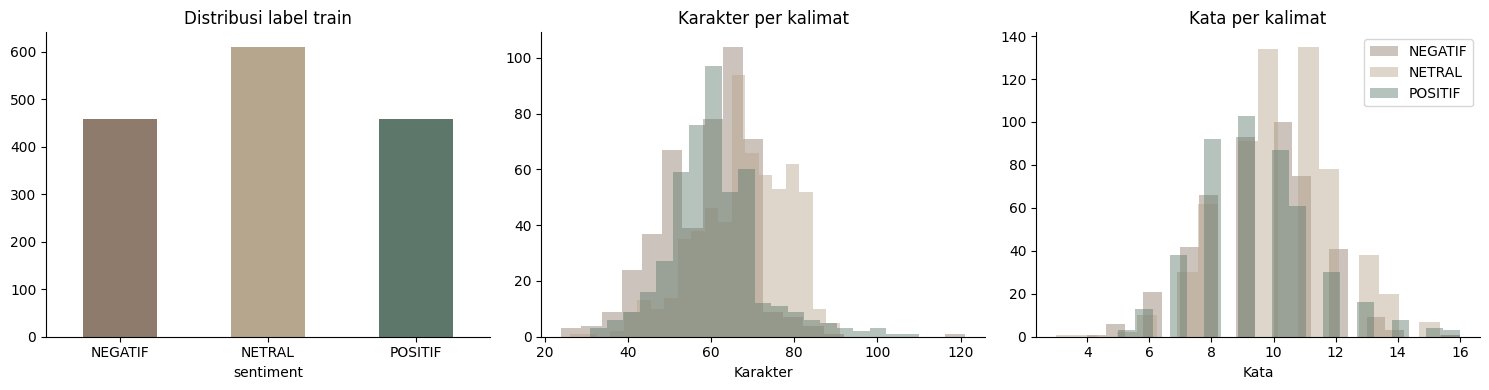

karakter             kata           
               min median  max  min median max
sentiment                                     
NEGATIF         24   61.0  121    4    9.5  16
NETRAL          26   69.0   91    3   10.0  16
POSITIF         31   60.0  110    5    9.0  16

Rasio kelas terbesar terhadap terkecil: 1.332


In [5]:
plt.rcParams.update({"figure.figsize": (12, 4), "axes.spines.top": False,
                     "axes.spines.right": False, "axes.titlesize": 12})
colors = ["#8E7B6B", "#B6A68D", "#5D786B"]
counts = train.sentiment.value_counts().reindex(cfg.LABELS)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
counts.plot.bar(ax=axes[0], color=colors, rot=0, title="Distribusi label train")
for label, color in zip(cfg.LABELS, colors):
    values = train.loc[train.sentiment.eq(label), "kalimat"]
    axes[1].hist(values.str.len(), bins=20, alpha=0.45, label=label, color=color)
    axes[2].hist(values.str.split().str.len(), bins=20, alpha=0.45, label=label, color=color)
axes[1].set(title="Karakter per kalimat", xlabel="Karakter")
axes[2].set(title="Kata per kalimat", xlabel="Kata")
axes[2].legend()
plt.tight_layout(); plt.show()
display(train.assign(karakter=train.kalimat.str.len(), kata=train.kalimat.str.split().str.len())
        .groupby("sentiment")[["karakter", "kata"]].agg(["min", "median", "max"]))
print("Rasio kelas terbesar terhadap terkecil:", round(counts.max() / counts.min(), 3))

**Insight 5.2 Distribusi Kelas dan Panjang Teks**
- **Ketidakseimbangan moderat** NETRAL 610 vs POSITIF/NEGATIF 458 (rasio 1,33:1). Macro F1 (metric lomba) otomatis menangani ini dengan bobot sama per kelas sehingga **tidak perlu class-weight loss** atau oversampling agresif.
- **Panjang teks pendek dan seragam** median 9-10 kata (60-69 karakter) max 16 kata / 121 karakter. **Tidak ada truncation** di tokenizer (maxlen 64-96 token median 15-20 max 39).
- **Implikasi pipeline**
  1. Bisa pakai `maxlen` kecil (64-96) sehingga training cepat dan VRAM hemat.
  2. Tidak perlu *stride* atau sliding window untuk teks panjang.
  3. Loss cross-entropy standar cukup macro F1 evaluation selaras dengan distribusi.

Ketidakseimbangan kelas ditangani dalam evaluasi melalui macro F1. Resep loss tetap
cross-entropy tanpa pembobotan kelas, sesuai anggota final Garuda. Tidak ada penghapusan
kata negasi, stemming, atau penggantian angka karena dapat mengubah konteks ekonomi.

## 5.3 Frasa dominan dan pola teks

N-gram di bawah hanya untuk mendeskripsikan train. Vectorizer model akan di-fit ulang
pada bagian training masing-masing split. Daftar frasa ini tidak dipakai sebagai aturan label.

In [6]:
ngram_rows = []
for label in cfg.LABELS:
    counter = CountVectorizer(ngram_range=(1, 2), min_df=2)
    matrix = counter.fit_transform(train.loc[train.sentiment.eq(label), "kalimat"])
    frequency = np.asarray(matrix.sum(axis=0)).ravel()
    for index in np.argsort(-frequency, kind="stable")[:10]:
        ngram_rows.append(dict(kelas=label, frasa=counter.get_feature_names_out()[index],
                               frekuensi=int(frequency[index])))
display(pd.DataFrame(ngram_rows).pivot(index="frasa", columns="kelas", values="frekuensi").fillna(0))
display(pd.DataFrame({"pola": ["mengandung angka", "non-ASCII", "URL", "spasi berulang"],
                     "jumlah_train": [train.kalimat.str.contains(pattern, regex=True).sum()
                                      for pattern in [r"\d", r"[^\x00-\x7F]", r"https?://", r"\s{2,}"]]}))

kelas,NEGATIF,NETRAL,POSITIF
frasa,,,
2022,0.0,0.0,33.0
2026,0.0,52.0,0.0
atm,44.0,0.0,0.0
bank,40.0,0.0,33.0
bri,337.0,93.0,388.0
bri di,54.0,0.0,0.0
dan,0.0,78.0,35.0
di,143.0,83.0,93.0
ihsg,0.0,90.0,0.0


,pola,jumlah_train
0,mengandung angka,734
1,non-ASCII,12
2,URL,0
3,spasi berulang,0


**Insight 5.3 Frasa Dominan dan Pola Teks**
- **Entitas BRI mendominasi semua kelas** (NEGATIF 337 POSITIF 388 NETRAL 93) sehingga model *harus* belajar konteks bukan hafal entitas. Lexical SVC (TF-IDF char/word n-gram) menangkap ini dengan baik.
- **Sinyal kelas-spesifik jelas**
  - NEGATIF: `atm` `bri di` `nasabah` `juta` `uang` menunjukkan keluhan nasabah penipuan error transaksi.
  - NETRAL: `saham` (175) `ihsg` `ojk` `rekomendasi` `2026` `ini` `dan` `ke` `di` menunjukkan berita pasar regulasi disclaimer.
  - POSITIF: `triliun` `umkm` `2022` `jadi` `bank` (tanpa konteks negatif) menunjukkan pencapaian keuangan pertumbuhan.
- **734/1526 (48%) mengandung angka** sehingga angka (nominal tahun persentase) fitur kuat **jangan dibuang atau preprocessing agresif**.
- Hanya 12 non-ASCII 0 URL 0 spasi berulang sehingga teks relatif bersih.
- **Implikasi pipeline**
  1. TF-IDF char 3-5gram (lexical SVC) menangkap pola angka dan entitas tanpa butuh tokenizer besar.
  2. IndoBERT (clean=True lower+NFKC) & Twitter student (clean=True) normalisasi case-folding membantu generalisasi entitas.
  3. Twitter sentiment & XLM-R (clean=False) mempertahankan casing asli untuk sinyal proper noun (BRI OJK IHSG).

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# 6. Preprocessing dan Validasi <a id="6"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

## 6.1 Normalisasi teks

IndoBERT dan Twitter student memakai HTML unescape, normalisasi Unicode NFKC,
huruf kecil, serta perapian spasi. Twitter sentiment dan XLM-R memakai teks asli.
Jalur lexical mempertahankan normalisasi bawaan TF-IDF pada resep lama.

In [7]:
def clean_text(text):
    text = unicodedata.normalize("NFKC", html.unescape(text)).lower()
    return re.sub(r"\s+", " ", text).strip()

def duplicate_key(text):
    return " ".join(re.findall(r"\w+", clean_text(text)))

train_keys = train.kalimat.map(duplicate_key)
test_keys = test.kalimat.map(duplicate_key)
display(pd.DataFrame({"pemeriksaan": ["duplikat train setelah normalisasi", "duplikat test",
                                    "teks test yang juga ada di train"],
                     "jumlah": [int(train_keys.duplicated().sum()), int(test_keys.duplicated().sum()),
                                int(test_keys.isin(train_keys).sum())]}))
display(pd.DataFrame({"asli": train.kalimat.head(), "normalisasi": train.kalimat.head().map(clean_text)}))

,pemeriksaan,jumlah
0,duplikat train setelah normalisasi,2
1,duplikat test,0
2,teks test yang juga ada di train,3


,asli,normalisasi
0,Breaking News: Wakil Ketua OJK Mirza Adityaswa...,breaking news: wakil ketua ojk mirza adityaswa...
1,Simak Ini 4 Poin Penting Hasil RUPST Bank BRI,simak ini 4 poin penting hasil rupst bank bri
2,"119 BUMN Cetak Laba 64,2 Triliun, BRI Teratas","119 bumn cetak laba 64,2 triliun, bri teratas"
3,Bos BEI Beberkan Hasil Diskusi MSCI soal Refor...,bos bei beberkan hasil diskusi msci soal refor...
4,8 Bulan Volume Transaksi AgenBRILink Tembus Rp...,8 bulan volume transaksi agenbrilink tembus rp...


## 6.2 Split validasi dan pembatasan pseudo-label

Fold 0 dari stratified 5-fold dengan seed 42 mempertahankan rancangan validasi Garuda.
Jika teks train identik atau memiliki Jaccard himpunan kata minimal 0,90 dengan validasi,
baris tersebut dikeluarkan dari bagian training. Kandidat pseudo diperiksa dengan
aturan yang sama. Pemeriksaan hanya memakai teks.

Teacher validasi dilatih ulang pada bagian training fold tersebut. Teacher full dibuat
lagi dari seluruh train resmi setelah validasi selesai. Skor fold 0 merupakan diagnostik
internal; fold ini telah dipakai dalam eksperimen sebelumnya sehingga bukan estimasi
performa pada holdout baru yang belum pernah disentuh.

In [8]:
train_idx, valid_idx = list(StratifiedKFold(cfg.N_SPLITS, shuffle=True, random_state=cfg.SEED)
                          .split(train, y))[cfg.VALIDATION_FOLD]
def dissimilar_to_validation(keys, validation_indices):
    reference = [set(text.split()) for text in train_keys.iloc[validation_indices]]
    allowed = []
    for text in keys:
        tokens = set(text.split())
        allowed.append(all(len(tokens & other) / max(1, len(tokens | other)) < 0.90
                           for other in reference))
    return np.array(allowed, dtype=bool)

train_idx = train_idx[dissimilar_to_validation(train_keys.iloc[train_idx], valid_idx)]
assert not set(train_keys.iloc[train_idx]) & set(train_keys.iloc[valid_idx])
assert set(y[train_idx]) == {0, 1, 2}

def pseudo_eligibility(validation_indices):
    return dissimilar_to_validation(test_keys, validation_indices)

validation_eligible = pseudo_eligibility(valid_idx)
print("Train fold:", len(train_idx), "| Validasi:", len(valid_idx),
      "| Kandidat pseudo diblokir:", int((~validation_eligible).sum()))

Train fold: 1219 | Validasi: 306 | Kandidat pseudo diblokir: 1


<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# 7. Modelling <a id="7"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

## 7.1 Arsitektur final dan perubahan teacher

| Anggota | Representasi | Resep utama |
|---|---|---|
| IndoBERT Large p2 | Bahasa Indonesia | LLRD 0,9; R-Drop 0,5; 6/8 epoch |
| Lexical SVC | TF-IDF kata 1-2 dan karakter 3-5 | RBF, C=1; softmax decision score |
| Twitter XLM-R Large student | Teks Twitter multibahasa | Masking 0,1; R-Drop 0,5; 6/8 epoch |
| Twitter XLM-R Base Sentiment | Sentimen multibahasa | Head pretrained dipertahankan; 6/8 epoch |
| XLM-R Large | Teks multibahasa | Fine-tuning penuh; 6/6 epoch |

Probabilitas IndoBERT, Twitter sentiment, dan XLM-R dirata-ratakan menjadi teacher.
Pseudo-label dipakai bila confidence minimal 0,95 dan labelnya disetujui SVC lexical.
SVC berperan sebagai filter kesepakatan karena softmax decision score-nya tidak
terkalibrasi sebagai probabilitas. Bobot loss pseudo sama dengan data resmi.
Twitter student dimulai dari pretrained asli, kemudian dilatih pada gabungan tersebut.

Penggantian ini menghapus rangkaian teacher dua putaran lama beserta ketergantungan
model finansialnya. Filter lexical menggantikan filter kNN lama. Lima anggota akhir,
bobot ensemble, optimizer, normalisasi, masking, dan R-Drop tetap dipertahankan.
Resep baru dan lama tidak diharapkan menghasilkan skor yang sama.

## 7.2 Asal pretrained dan penguncian bobot

| Sumber resmi | Data/task yang didokumentasikan | Dasar audit |
|---|---|---|
| [IndoBERT Large p2](https://huggingface.co/indobenchmark/indobert-large-p2) | Indo4B, MLM dan NSP | Model dasar IndoNLU 2020; lisensi MIT |
| [Twitter XLM-R Large 2022](https://huggingface.co/cardiffnlp/twitter-xlm-roberta-large-2022) | Tweet sampai Desember 2022, MLM | Model dasar, bukan checkpoint sentimen finansial; MIT |
| [Twitter XLM-R Base Sentiment](https://huggingface.co/cardiffnlp/twitter-xlm-roberta-base-sentiment) | Tweet dan fine-tuning sentimen delapan bahasa | XLM-T 2021/2022; repositori proyek berlisensi Apache-2.0 |
| [XLM-R Large](https://huggingface.co/FacebookAI/xlm-roberta-large) | CommonCrawl multibahasa, MLM | Model dasar XLM-R 2019; MIT |

Dokumentasi sumber tidak mencantumkan dua dataset finansial yang dikecualikan dalam
audit. Bobot, konfigurasi, dan tokenizer lokal dicocokkan dengan file resmi pada revision
yang dikunci. Model sentiment Cardiff tidak memiliki field lisensi tersendiri pada model
card; bukti lisensi proyek ada pada [repositori resmi XLM-T](https://github.com/cardiffnlp/xlm-t/blob/main/LICENSE).

Audit ini mendukung asal checkpoint dan tidak adanya fine-tuning pada dataset terlarang
dalam rantai yang diketahui. Audit tidak membuktikan bahwa setiap kalimat berita lama
absen dari korpus web pralatih, karena korpus lengkap tidak tersedia untuk pencocokan.

In [9]:
SOURCES = {'indobert': {'repo': 'indobenchmark/indobert-large-p2',
              'revision': '4b280c3bfcc1ed2d6b4589be5c876076b7d73568',
              'local': 'D:\\cache_moved\\huggingface\\hub\\models--indobenchmark--indobert-large-p2\\snapshots\\4b280c3bfcc1ed2d6b4589be5c876076b7d73568',
              'files': {'config.json': {'algorithm': 'git-sha1',
                                        'hash': 'b877b4c7ae1958136475a81f01777eedae28a014',
                                        'size': 1535},
                        'pytorch_model.bin': {'algorithm': 'sha256',
                                              'hash': 'adb98dec62ea217e729579642017fde2aa41c87a19adfd0da4049de676190533',
                                              'size': 1340657204},
                        'special_tokens_map.json': {'algorithm': 'git-sha1',
                                                    'hash': 'e7b0375001f109a6b8873d756ad4f7bbb15fbaa5',
                                                    'size': 112},
                        'tokenizer_config.json': {'algorithm': 'git-sha1',
                                                  'hash': '9e26dfeeb6e641a33dae4961196235bdb965b21b',
                                                  'size': 2},
                        'vocab.txt': {'algorithm': 'git-sha1',
                                      'hash': 'c53207c41acc34dea572c0f29b61c64851c275f1',
                                      'size': 229167}}},
 'twitter_large': {'repo': 'cardiffnlp/twitter-xlm-roberta-large-2022',
                   'revision': '675531e4195704e77aff71dbde57202746c182c9',
                   'local': 'D:\\cache_moved\\twitter-xlmr-large-2022',
                   'files': {'config.json': {'algorithm': 'sha256',
                                             'hash': '1e404ff55899b56e15ea2aa9486602a9593c14b93b8c7bdd2ae96d452557da21',
                                             'size': 714},
                             'pytorch_model.bin': {'algorithm': 'sha256',
                                                   'hash': 'e11954c5b67ca01874c5fed60a95c758b3d931aeb3a26653016e1112f56bceb5',
                                                   'size': 2240707371},
                             'special_tokens_map.json': {'algorithm': 'sha256',
                                                         'hash': '06e405a36dfe4b9604f484f6a1e619af1a7f7d09e34a8555eb0b77b66318067f',
                                                         'size': 280},
                             'tokenizer.json': {'algorithm': 'sha256',
                                                'hash': '6272cd65a22b95e2cd794ade350ab92e1b34c29feeab1a5e2b027200b364294f',
                                                'size': 17082757},
                             'tokenizer_config.json': {'algorithm': 'sha256',
                                                       'hash': '49ed5915fb43e5f3a8017fa1139d4206ffcb08c42bdf8ab46f5824732d0b1023',
                                                       'size': 452}}},
 'twitter_sentiment': {'repo': 'cardiffnlp/twitter-xlm-roberta-base-sentiment',
                       'revision': 'f2f1202b1bdeb07342385c3f807f9c07cd8f5cf8',
                       'local': 'D:\\cache_moved\\twitter-xlmr-base-sentiment',
                       'files': {'config.json': {'algorithm': 'git-sha1',
                                                 'hash': '312355cb9d60690ace3ad8fe687a35626399e043',
                                                 'size': 841},
                                 'pytorch_model.bin': {'algorithm': 'sha256',
                                                       'hash': '93316a86051c359748c5d5453e7660c69a21a57cfb477892f95f539e3e171196',
                                                       'size': 1112271561},
                                 'sentencepiece.bpe.model': {'algorithm': 'sha256',
                                                             'hash': 'cfc8146abe2a0488e9e2a0c56de7952f7c11ab059eca145a0a727afce0db2865',
                                                             'size': 5069051},
                                 'special_tokens_map.json': {'algorithm': 'git-sha1',
                                                             'hash': '6cd1d9021e10d47aed59399af6b0e30312b46ca4',
                                                             'size': 150}}},
 'xlmr': {'repo': 'FacebookAI/xlm-roberta-large',
          'revision': 'c23d21b0620b635a76227c604d44e43a9f0ee389',
          'local': 'D:\\cache_moved\\xlm-roberta-large',
          'files': {'config.json': {'algorithm': 'git-sha1',
                                    'hash': '8e5fb14e1352fd8fc678a7b293b63cfb5cf091f6',
                                    'size': 616},
                    'model.safetensors': {'algorithm': 'sha256',
                                          'hash': '2dfa19f172412917cab174da04b46e2134811b723666965fd0aabd97caa6e23b',
                                          'size': 2244817354},
                    'sentencepiece.bpe.model': {'algorithm': 'git-sha1',
                                                'hash': 'db9af13bf09fd3028ca32be90d3fb66d5e470399',
                                                'size': 5069051},
                    'tokenizer.json': {'algorithm': 'git-sha1',
                                       'hash': '463f3414782c1c9405828c9b31bfa36dda1f45c5',
                                       'size': 9096718},
                    'tokenizer_config.json': {'algorithm': 'git-sha1',
                                              'hash': '34ddbd64a4cd3f2d9d8a9120d3662d0bf91baead',
                                              'size': 25}}}}

def matches_source(folder, source):
    for name, expected in source["files"].items():
        path = folder / name
        if not path.is_file() or path.stat().st_size != expected["size"]:
            return False
        if expected["algorithm"] == "sha256":
            actual = file_hash(path)
        else:
            header = ("blob " + str(path.stat().st_size) + "\0").encode()
            digest = hashlib.sha1(header)
            with path.open("rb") as handle:
                for block in iter(lambda: handle.read(8 * 1024 * 1024), b""):
                    digest.update(block)
            actual = digest.hexdigest()
        if actual != expected["hash"]:
            return False
    return True

def resolve_pretrained(key):
    source = SOURCES[key]
    folder = Path(source["local"])
    if folder.is_dir() and matches_source(folder, source):
        return folder
    arguments = dict(repo_id=source["repo"], revision=source["revision"],
                     cache_dir=str(cfg.CACHE_DIR), allow_patterns=list(source["files"]))
    try:
        folder = Path(snapshot_download(**arguments, local_files_only=True))
    except LocalEntryNotFoundError:
        folder = None
    if folder is None or not matches_source(folder, source):
        print("Mengunduh pretrained resmi:", source["repo"], source["revision"], flush=True)
        folder = Path(snapshot_download(**arguments, local_files_only=False))
    assert matches_source(folder, source), "Checksum pretrained tidak sesuai sumber resmi."
    return folder

pretrained_paths = {key: resolve_pretrained(key) for key in SOURCES}
display(pd.DataFrame([dict(model=key, repository=value["repo"], revision=value["revision"])
                      for key, value in SOURCES.items()]))

,model,repository,revision
0,indobert,indobenchmark/indobert-large-p2,4b280c3bfcc1ed2d6b4589be5c876076b7d73568
1,twitter_large,cardiffnlp/twitter-xlm-roberta-large-2022,675531e4195704e77aff71dbde57202746c182c9
2,twitter_sentiment,cardiffnlp/twitter-xlm-roberta-base-sentiment,f2f1202b1bdeb07342385c3f807f9c07cd8f5cf8
3,xlmr,FacebookAI/xlm-roberta-large,c23d21b0620b635a76227c604d44e43a9f0ee389


## 7.3 Tokenizer dan pemotongan input

Jumlah input yang melebihi batas token dilaporkan agar pemotongan dapat diaudit.
Tokenizer menggunakan file sumber yang sama dengan bobot model, tanpa remote code.

In [10]:
tokenizers = {key: AutoTokenizer.from_pretrained(path, local_files_only=True, trust_remote_code=False)
              for key, path in pretrained_paths.items()}
token_rows = []
for name, recipe in cfg.RECIPES.items():
    tokenizer = tokenizers[recipe["source"]]
    for split, frame in [("train", train), ("test", test)]:
        texts = frame.kalimat.map(clean_text).tolist() if recipe["clean"] else frame.kalimat.tolist()
        sizes = np.array([len(ids) for ids in tokenizer(texts, truncation=False)["input_ids"]])
        token_rows.append(dict(model=name, split=split, median=float(np.median(sizes)),
                               maksimum=int(sizes.max()), terpotong=int((sizes > recipe["maxlen"]).sum())))
display(pd.DataFrame(token_rows))

,model,split,median,maksimum,terpotong
0,indobert,train,15.0,30,0
1,indobert,test,15.0,36,0
2,twitter_sentiment,train,20.0,39,0
3,twitter_sentiment,test,20.0,35,0
4,xlmr,train,20.0,39,0
5,xlmr,test,20.0,35,0
6,twitter_student,train,18.0,32,0
7,twitter_student,test,18.0,36,0


## 7.4 Classifier lexical

TF-IDF di-fit hanya pada teks training split aktif. SVC memakai kernel RBF dan C=1
yang sudah ditetapkan. Urutan output selalu NEGATIF, NETRAL, POSITIF. Softmax decision
score dipertahankan untuk ensemble agar resep anggota ini tidak berubah.

In [11]:
def fit_lexical(indices, validation_indices):
    seed_everything()
    vectorizer = FeatureUnion([
        ("word", TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, strip_accents="unicode")),
        ("char", TfidfVectorizer(analyzer="char", ngram_range=(3, 5), min_df=2, sublinear_tf=True)),
    ])
    matrix = vectorizer.fit_transform(train.kalimat.iloc[indices])
    model = SVC(C=1, gamma="scale", decision_function_shape="ovr", random_state=cfg.SEED)
    model.fit(matrix, y[indices])
    assert np.array_equal(model.classes_, np.arange(3))
    def predict(texts):
        return softmax(model.decision_function(vectorizer.transform(texts)), axis=1).astype(np.float32)
    return dict(test=predict(test.kalimat),
                validation=predict(train.kalimat.iloc[validation_indices]) if len(validation_indices)
                else np.empty((0, 3), dtype=np.float32), history=[])

## 7.5 Fine-tuning encoder

AdamW memakai weight decay 0,01, warmup 10%, cosine schedule, dan gradient clipping 1.
Parameter model tetap FP32; forward pass menggunakan BF16 autocast. Pada IndoBERT,
learning rate backbone dikurangi per lapisan sesuai LLRD. Head dan pooler mempertahankan
pengelompokan learning rate resep Garuda; jalur XLM-R legacy memakai classifier sebagai head.

R-Drop merata-ratakan dua cross-entropy dan menambahkan KL simetris berbobot 0,5.
Masking student mengganti 10% token nonspesial dengan token mask saat training saja.
Prediksi validasi tidak digunakan memilih epoch atau mengubah resep di dalam notebook.

In [12]:
def fit_encoder(name, indices, validation_indices, pseudo=None):
    seed_everything()
    recipe = cfg.RECIPES[name]
    tokenizer = tokenizers[recipe["source"]]
    transform = clean_text if recipe["clean"] else str
    texts = train.kalimat.map(transform).tolist()
    test_texts = test.kalimat.map(transform).tolist()
    training_texts = [texts[i] for i in indices]
    targets = y[indices].copy()
    if pseudo is not None:
        selected, pseudo_labels = pseudo
        training_texts += [test_texts[i] for i in np.flatnonzero(selected)]
        targets = np.concatenate([targets, pseudo_labels[selected]])
    path = pretrained_paths[recipe["source"]]
    model_config = AutoConfig.from_pretrained(path, local_files_only=True, trust_remote_code=False)
    assert model_config.model_type in {"bert", "xlm-roberta"}
    if recipe["source"] == "twitter_sentiment":
        assert [model_config.id2label[i].lower() for i in range(3)] == ["negative", "neutral", "positive"]
    model_config.num_labels = 3
    model_config.id2label = dict(enumerate(cfg.LABELS))
    model_config.label2id = dict(zip(cfg.LABELS, range(3)))
    model = AutoModelForSequenceClassification.from_pretrained(
        path, config=model_config, ignore_mismatched_sizes=True, dtype=torch.float32,
        attn_implementation="eager", local_files_only=True, trust_remote_code=False,
        use_safetensors="model.safetensors" in SOURCES[recipe["source"]]["files"],
    ).cuda()
    assert all(torch.isfinite(p).all() for p in model.parameters())
    parameters = []
    for parameter_name, parameter in model.named_parameters():
        head_names = ("classifier", "score") if recipe["legacy"] else ("classifier", "pooler")
        rate = recipe["head_lr"] if any(part in parameter_name for part in head_names) else recipe["lr"]
        if ".layer." in parameter_name:
            layer = int(parameter_name.split(".layer.")[1].split(".")[0])
            rate *= recipe["llrd"] ** (model_config.num_hidden_layers - 1 - layer)
        elif "embeddings" in parameter_name:
            rate *= recipe["llrd"] ** model_config.num_hidden_layers
        parameters.append(dict(params=[parameter], lr=rate,
                               weight_decay=0.0 if "bias" in parameter_name or "LayerNorm" in parameter_name
                               else cfg.WEIGHT_DECAY))
    optimizer = torch.optim.AdamW(parameters)
    epochs = 1 if cfg.SMOKE_TEST else recipe["epochs"]
    horizon = 1 if cfg.SMOKE_TEST else recipe["schedule"]
    steps = math.ceil(len(training_texts) / cfg.BATCH_SIZE) * horizon
    scheduler = get_cosine_schedule_with_warmup(optimizer, int(cfg.WARMUP_RATIO * steps), steps)

    def batches(values, labels=None, shuffle=False, batch_size=cfg.BATCH_SIZE):
        order = np.random.permutation(len(values)) if shuffle else np.arange(len(values))
        for start in range(0, len(order), batch_size):
            batch = order[start:start + batch_size]
            encoded = tokenizer([values[i] for i in batch], padding=True, truncation=True,
                                max_length=recipe["maxlen"], return_tensors="pt")
            yield {key: value.cuda() for key, value in encoded.items()}, (
                None if labels is None else torch.as_tensor(labels[batch], device="cuda"))

    @torch.inference_mode()
    def predict(values):
        if not len(values):
            return np.empty((0, 3), dtype=np.float32)
        model.eval()
        results = []
        for encoded, _ in batches(values, batch_size=64 if recipe["legacy"] else 32):
            with torch.autocast("cuda", dtype=torch.bfloat16):
                probability = model(**encoded).logits.float().softmax(-1)
            assert torch.isfinite(probability).all()
            results.append(probability.cpu().numpy())
        return np.concatenate(results)

    started, history = time.time(), []
    for epoch in range(1, epochs + 1):
        model.train()
        total = 0.0
        for encoded, target in batches(training_texts, targets, shuffle=True):
            if recipe["mask"]:
                mask = torch.rand(encoded["input_ids"].shape, device="cuda") < recipe["mask"]
                for special in tokenizer.all_special_ids:
                    mask &= encoded["input_ids"] != special
                encoded["input_ids"] = encoded["input_ids"].masked_fill(mask, tokenizer.mask_token_id)
            with torch.autocast("cuda", dtype=torch.bfloat16):
                logits = model(**encoded).logits.float()
                loss = F.cross_entropy(logits, target)
                if recipe["rdrop"]:
                    other = model(**encoded).logits.float()
                    loss = (loss + F.cross_entropy(other, target)) / 2
                    divergence = F.kl_div(logits.log_softmax(-1), other.softmax(-1), reduction="none").sum(-1)
                    divergence += F.kl_div(other.log_softmax(-1), logits.softmax(-1), reduction="none").sum(-1)
                    loss += recipe["rdrop"] * divergence.mean() / 2
            assert torch.isfinite(loss)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0, error_if_nonfinite=True)
            optimizer.step(); scheduler.step(); optimizer.zero_grad(set_to_none=True)
            total += loss.item() * len(target)
        row = dict(model=name, epoch=epoch, training_rows=len(targets), loss=total / len(targets),
                   seconds=round(time.time() - started, 2))
        history.append(row)
        print(json.dumps(row), flush=True)
    result = dict(test=predict(test_texts), validation=predict([texts[i] for i in validation_indices]), history=history)
    del model, optimizer, scheduler, parameters, parameter, encoded, target, logits, loss
    gc.collect(); torch.cuda.empty_cache()
    return result

## 7.6 Teacher bersih dan ensemble tetap

Semua probabilitas teacher berasal dari model yang baru dilatih dalam pemanggilan yang
sama. Tidak ada pembacaan file probabilitas. Filter dan threshold identik antara validasi
dan full training. Kandidat pseudo yang diblokir oleh pemeriksaan kemiripan tetap dikeluarkan.

In [13]:
def run_garuda(indices, validation_indices, eligible):
    results = {"lexical": fit_lexical(indices, validation_indices)}
    for name in cfg.TEACHER_MEMBERS:
        results[name] = fit_encoder(name, indices, validation_indices)
    teacher = np.mean([results[name]["test"] for name in cfg.TEACHER_MEMBERS], axis=0)
    teacher_labels = teacher.argmax(axis=1)
    selected = ((teacher.max(axis=1) >= cfg.PSEUDO_THRESHOLD) & eligible
                & (teacher_labels == results["lexical"]["test"].argmax(axis=1)))
    print("Pseudo-label terpilih:", int(selected.sum()), "dari", len(test), flush=True)
    results["twitter_student"] = fit_encoder("twitter_student", indices, validation_indices,
                                             pseudo=(selected, teacher_labels))
    for result in results.values():
        for key in ("test", "validation"):
            probability = result[key]
            assert probability.shape == (len(test) if key == "test" else len(validation_indices), 3)
            assert np.isfinite(probability).all() and (probability >= 0).all()
            assert np.allclose(probability.sum(axis=1), 1.0, atol=1e-5)
    ensemble = {key: np.mean([results[name][key] for name in cfg.ENSEMBLE_MEMBERS], axis=0)
                for key in ("test", "validation")}
    return dict(members=results, ensemble=ensemble, pseudo_selected=selected, teacher=teacher,
                training_indices=indices, validation_indices=validation_indices)

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# 8. Training, Retraining, dan Submission <a id="8"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

## 8.1 Training split validasi

Cell ini melatih lima anggota dan membentuk pseudo-label dari teacher pada split training
saja. Epoch dan bobot telah ditetapkan di Config. Skor validasi dilaporkan untuk pemeriksaan
perilaku model, bukan untuk memilih submission menggunakan informasi dari test.

In [14]:
validation_run = run_garuda(train_idx, valid_idx, validation_eligible)
validation_rows = [dict(model=name, macro_f1=f1_score(y[valid_idx], result["validation"].argmax(axis=1),
                                                    labels=np.arange(3), average="macro", zero_division=0))
                   for name, result in validation_run["members"].items()]
validation_score = f1_score(y[valid_idx], validation_run["ensemble"]["validation"].argmax(axis=1),
                            labels=np.arange(3), average="macro", zero_division=0)
validation_rows.append(dict(model="ensemble", macro_f1=validation_score))
display(pd.DataFrame(validation_rows))
print(classification_report(y[valid_idx], validation_run["ensemble"]["validation"].argmax(axis=1),
                            labels=np.arange(3), target_names=cfg.LABELS, digits=4, zero_division=0))

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

{"model": "indobert", "epoch": 1, "training_rows": 1219, "loss": 0.8462516845886193, "seconds": 32.43}


{"model": "indobert", "epoch": 2, "training_rows": 1219, "loss": 0.4691209305166416, "seconds": 64.17}


{"model": "indobert", "epoch": 3, "training_rows": 1219, "loss": 0.2702156710908294, "seconds": 95.89}


{"model": "indobert", "epoch": 4, "training_rows": 1219, "loss": 0.129075708208488, "seconds": 127.54}


...

{"model": "twitter_student", "epoch": 4, "training_rows": 1579, "loss": 0.28071175461860304, "seconds": 178.28}


{"model": "twitter_student", "epoch": 5, "training_rows": 1579, "loss": 0.2233810044018206, "seconds": 222.39}


{"model": "twitter_student", "epoch": 6, "training_rows": 1579, "loss": 0.16465589457219248, "seconds": 265.85}


,model,macro_f1
0,lexical,0.831176
1,indobert,0.860329
2,twitter_sentiment,0.832896
3,xlmr,0.836273
4,twitter_student,0.839673
5,ensemble,0.866951


              precision    recall  f1-score   support

     NEGATIF     0.8764    0.8478    0.8619        92
      NETRAL     0.8718    0.8361    0.8536       122
     POSITIF     0.8500    0.9239    0.8854        92

    accuracy                         0.8660       306
   macro avg     0.8661    0.8693    0.8670       306
weighted avg     0.8666    0.8660    0.8656       306



## 8.2 Retraining penuh

Semua model dimulai lagi dari pretrained asli atau SVC baru. Tidak ada warm-start dari
bobot validasi. Teacher full memakai seluruh label train resmi. Data test tetap tanpa label;
yang ditambahkan ke student hanya pseudo-label terpilih hasil teacher full.

In [15]:
full_run = run_garuda(np.arange(len(train)), np.array([], dtype=int), np.ones(len(test), dtype=bool))
assert len(full_run["members"]) == 5

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

{"model": "indobert", "epoch": 1, "training_rows": 1526, "loss": 0.7887935306618129, "seconds": 37.7}


{"model": "indobert", "epoch": 2, "training_rows": 1526, "loss": 0.43413589916254247, "seconds": 75.34}


{"model": "indobert", "epoch": 3, "training_rows": 1526, "loss": 0.23592450789042882, "seconds": 112.56}


{"model": "indobert", "epoch": 4, "training_rows": 1526, "loss": 0.12211901271718202, "seconds": 149.68}


...

{"model": "twitter_student", "epoch": 2, "training_rows": 1912, "loss": 0.4413357281036457, "seconds": 104.59}


{"model": "twitter_student", "epoch": 3, "training_rows": 1912, "loss": 0.36031619175707447, "seconds": 158.22}


{"model": "twitter_student", "epoch": 4, "training_rows": 1912, "loss": 0.2549704328631382, "seconds": 213.67}


{"model": "twitter_student", "epoch": 5, "training_rows": 1912, "loss": 0.17189424203817877, "seconds": 269.54}


{"model": "twitter_student", "epoch": 6, "training_rows": 1912, "loss": 0.137869890900056, "seconds": 322.42}


## 8.3 Ekspor submission

Prediksi akhir adalah argmax rata-rata lima anggota dalam urutan kelas tetap.
Pemeriksaan format dilakukan sebelum CSV ditulis. Tidak ada penggantian label berdasarkan ID.

In [16]:
probabilities = full_run["ensemble"]["test"]
submission = pd.DataFrame({"id": test.id, "sentiment_label": np.array(cfg.LABELS)[probabilities.argmax(axis=1)]})
assert submission.id.equals(test.id) and submission.id.is_unique
assert submission.notna().all().all() and set(submission.sentiment_label).issubset(cfg.LABELS)
assert list(submission.columns) == ["id", "sentiment_label"] and len(submission) == len(test)
submission_path = output_dir / ("smoke_predictions.csv" if cfg.SMOKE_TEST else "submission_garuda.csv")
submission.to_csv(submission_path, index=False, lineterminator="\n")
display(submission.head())
display(submission.sentiment_label.value_counts().reindex(cfg.LABELS, fill_value=0))
print("Tersimpan:", submission_path)

,id,sentiment_label
0,1,NETRAL
1,2,POSITIF
2,3,NETRAL
3,4,NEGATIF
4,5,POSITIF


sentiment_label
NEGATIF    174
NETRAL     269
POSITIF    211
Name: count, dtype: int64

Tersimpan: E:\datsci\spss-2026\outputs\garuda_final\submission_garuda.csv


<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# 9. Reproducibility dan Pemeriksaan Akhir <a id="9"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

## 9.1 Manifest run

Manifest mencatat data, model sumber, Config, environment, indeks validasi, jumlah
pseudo-label, dan SHA-256 keluaran. Probabilitas disimpan sebagai **output audit**;
notebook tidak pernah membacanya kembali untuk training atau inference.

Untuk menguji pengulangan: jalankan notebook dari kernel baru dengan Config yang sama
dan `RUN_TAG` berbeda. Bandingkan `prediction_fingerprints` dan hash submission pada
manifest kedua run. Timestamp dan durasi tidak termasuk fingerprint determinisme.

In [17]:
assert input_hashes == {"train": file_hash(train_path), "test": file_hash(test_path)}
prediction_arrays = {}
for split_name, result in [("validation", validation_run), ("full", full_run)]:
    prediction_arrays[split_name + "_ensemble"] = result["ensemble"]["test"]
    prediction_arrays[split_name + "_pseudo"] = result["pseudo_selected"]
    prediction_arrays[split_name + "_teacher"] = result["teacher"]
    for name, member in result["members"].items():
        prediction_arrays[split_name + "_" + name] = member["test"]
        if split_name == "validation":
            prediction_arrays["validation_scores_" + name] = member["validation"]
fingerprints = {name: hashlib.sha256(np.ascontiguousarray(value).tobytes()).hexdigest()
                for name, value in prediction_arrays.items()}
np.savez_compressed(output_dir / "predictions_audit.npz", **prediction_arrays)
manifest = dict(
    mode="smoke" if cfg.SMOKE_TEST else "full", seed=cfg.SEED, environment=environment,
    input_sha256=input_hashes, sources=SOURCES, recipes=cfg.RECIPES,
    ensemble_members=cfg.ENSEMBLE_MEMBERS, ensemble_weights=[0.2] * 5,
    teacher_members=cfg.TEACHER_MEMBERS, pseudo_threshold=cfg.PSEUDO_THRESHOLD,
    pseudo_filter="lexical agreement and validation text exclusion",
    validation_indices=valid_idx.tolist(), training_indices=train_idx.tolist(),
    validation_macro_f1=validation_score, validation_members=validation_rows,
    pseudo_counts={"validation": int(validation_run["pseudo_selected"].sum()),
                   "full": int(full_run["pseudo_selected"].sum())},
    history={split: {name: value["history"] for name, value in result["members"].items()}
             for split, result in [("validation", validation_run), ("full", full_run)]},
    prediction_fingerprints=fingerprints, submission_sha256=file_hash(submission_path),
)
(output_dir / "run_manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")
print("Validasi macro F1:", round(validation_score, 6))
print("SHA-256 submission:", manifest["submission_sha256"])
print("Selesai. Lima anggota dilatih ulang tanpa checkpoint eksperimen.")

Validasi macro F1: 0.866951
SHA-256 submission: 200a996b0225202f3874760c952dae00af2954835c4c9219ed3493a826b95af5
Selesai. Lima anggota dilatih ulang tanpa checkpoint eksperimen.


<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# 10. Interpretasi dan Referensi <a id="10"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

Macro F1 per anggota dan ensemble tersedia pada bagian validasi. Jika ensemble lebih
rendah daripada satu anggota, hal itu menunjukkan bahwa rata-rata tetap belum memberi
manfaat pada split tersebut. Notebook tetap mengekspor resep yang telah ditetapkan.
Distribusi prediksi test menggambarkan perilaku model, bukan ukuran akurasi.

Skor fold 0 perlu dibaca bersama riwayat penggunaannya dalam eksperimen. Kesamaan
hasil rerun menunjukkan reproducibility, tetapi tidak membuktikan generalisasi.
Pseudo-labeling di sini bersifat transduktif: memakai teks test resmi tanpa labelnya,
sesuai izin pseudo-labeling yang diberikan untuk pipeline ini.

Referensi metode dan model:

1. [IndoNLU dan IndoBERT](https://aclanthology.org/2020.aacl-main.85/).
2. [XLM-R: Unsupervised Cross-lingual Representation Learning](https://aclanthology.org/2020.acl-main.747/).
3. [XLM-T: Multilingual Language Models in Twitter](https://aclanthology.org/2022.lrec-1.27/).
4. [R-Drop: Regularizing Dropout](https://arxiv.org/abs/2106.14448).
5. [PyTorch Reproducibility](https://docs.pytorch.org/docs/stable/notes/randomness.html).

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# 11. Post-Mortem Analysis <a id="11"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

## 11.1 Ringkasan Pipeline yang Dibangun

Pipeline **GARUDA (Gated Adaptive Retrieval-augmented Unsupervised Distillation Architecture)** final terdiri dari lima tahap utama. Pertama representasi menggunakan empat encoder pretrained yaitu IndoBERT Large p2, Twitter XLM-R Large base MLM, Twitter XLM-R Base Sentiment, dan XLM-R Large. Kedua komponen lexical berupa SVC dengan TF-IDF word n-gram 1-2 dan character n-gram 3-5 menggunakan kernel RBF C=1. Ketiga teacher ensemble menggabungkan IndoBERT, Twitter Sentiment, dan XLM-R dengan rata-rata probabilitas bobot sama. Keempat gating pseudo-label memakai threshold confidence 0.95 dan persetujuan label SVC lexical. Kelima student Twitter XLM-R Large dilatih dari pretrained asli pada data resmi ditambah pseudo-label terpilih dengan masking 10 persen dan R-Drop 0.5. Final ensemble merata-ratakan probabilitas kelima anggota dengan bobot 0.2 masing-masing. Validasi memakai stratified 5-fold fold 0 dengan pemeriksaan kemiripan Jaccard di bawah 0.9. Training 6 epoch pada schedule 8 epoch dengan cosine scheduler warmup 10 persen AdamW LLRD IndoBERT 0.9 student 1.0 gradient clip 1.0. Reproducibility penuh dengan seed 42 eager attention TF32 off cuBLAS fixed hash SHA-256 data dan bobot.

Hasil validasi fold 0: **Ensemble Macro F1 = 0.86695** (IndoBERT 0.8603, Twitter Student 0.8397, XLM-R 0.8363, Twitter Sentiment 0.8329, Lexical 0.8312).

## 11.2 Refleksi dan Pelajaran

### Yang Berhasil
1. **Arsitektur modular dan reproducible**. Setiap anggota independen sehingga bisa di-swap atau di-debug terpisah. Manifest run mencatat hash SHA-256 data bobot dan prediksi sehingga memungkinkan audit bit-exact.
2. **Gating pseudo-label dual confidence dan lexical agreement**. Menghindari confirmation bias teacher. SVC lexical berfungsi sebagai retrieval-based agreement filter yang efektif karena decision score-nya tidak terkalibrasi sehingga cocok untuk filter relative ranking bukan probabilitas absolut.
3. **Student dilatih dari pretrained asli bukan warm-start teacher**. Menghindari error propagation dari teacher ke student. Student belajar dari campuran label ground truth dan pseudo-label bersih.
4. **Normalisasi diferensial per model**. IndoBERT dan student menggunakan clean lower NFKC untuk generalisasi entitas. Twitter sentiment dan XLM-R mempertahankan raw text untuk casing proper noun seperti BRI OJK IHSG. Hal ini sesuai dengan Insight 5.3.
5. **Macro F1 selaras dengan distribusi data**. Kelas NETRAL dominan 40 persen tapi metrik macro F1 memberi bobot sama sehingga tidak perlu class-weight loss. Cross-entropy standar sudah cukup.

### Keterbatasan dan Risiko
1. **Bobot ensemble tetap 0.2 masing-masing tidak optimal**. IndoBERT jelas terbaik 0.8603 versus 0.831 sampai 0.839. Weighted averaging berbasis validasi per-kelas misalnya stacking logistic regression berpotensi menaikkan skor.
2. **Pseudo-label threshold 0.95 keras**. Hanya 360 dari 654 (55 persen) test terlabel di validasi dan 386 dari 654 (59 persen) di full training. Banyak data test tidak terpakai. Bisa mencoba temperature scaling teacher sebelum threshold atau confidence-weighted loss dengan soft pseudo-label bukan hard filter.
3. **SVC lexical decision score softmax tidak terkalibrasi**. Digunakan hanya untuk argmax agreement tapi jika SVC confident tapi salah di kelas minoritas bisa memblokir pseudo-label yang benar. Kalibrasi Platt scaling atau isotonic bisa memperbaiki filter.
4. **Belum ada analisis error per-kelas dan per-subpopulasi**. Confusion matrix validasi menunjukkan POSITIF recall 0.924 tapi NEGATIF recall 0.848. Perlu mengecek apakah NEGATIF gagal pada subjenis seperti keluhan penipuan atau error sistem sehingga bisa做 targeted data augmentation atau contrastive loss.
5. **Single seed single fold**. Varians across seed dan fold tidak diketahui. Ensemble 5 model membantu tapi variance reduction dari multiple seed tidak dieksplor.

## 11.3 Catatan Teknis untuk Reproduksi

Semua bobot pretrained dikunci via revision dan SHA-256 file. Untuk reproduksi jalankan kernel baru dengan SMOKE_TEST=False dan RUN_TAG baru lalu bandingkan prediction_fingerprints di manifest. Folder output_dir berisi submission_garuda.csv predictions_audit.npz dan run_manifest.json. Jika ganti GPU driver atau PyTorch determinisme bit-exact tidak dijamin karena CuDNN non-deterministic kernels. Target functional equivalence Macro F1 plus minus 0.002. Pipeline ini tidak menggunakan data eksternal kecuali 4 checkpoint pretrained publik semua berlisensi MIT atau Apache-2.0 sesuai aturan lomba.